# Vietnam Job Market Clustering - Pipeline Huấn luyện (Training Pipeline)

Notebook này thực hiện **Giai đoạn 3: Phân cụm & Đánh giá Chất lượng** trực tiếp trên không gian đặc trưng **160 chiều gốc** đã chuẩn hóa để bảo toàn metric Euclidean gốc.
Các bước tiền xử lý dữ liệu (Phase 1) và trích xuất đặc trưng (Phase 2) đã được thực hiện tự động và lưu trữ trước bằng các kịch bản độc lập (`preprocess.py` và `feature_engineering.py`) nhằm tối ưu hóa thời gian huấn luyện. Notebook này sẽ trực tiếp tải các tệp đặc trưng đã được chuẩn hóa để khảo sát số cụm tối ưu và xây dựng mô hình phân cụm cuối cùng.

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


# Setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)
%matplotlib inline

## Bước 1: Nạp Dữ liệu Sạch & Ma trận Đặc trưng số
Chúng ta nạp dữ liệu sạch `results/clean_data_train_final.csv` cùng ma trận đặc trưng 169D từ tệp lưu trữ đặc trưng `results/features_train.npz`.

In [32]:
print("Loading clean train dataset and features...")
df_train_final = pd.read_csv('../results/clean_data_train_final.csv')
train_features = np.load('../results/features_train.npz')

full_train_scaled = train_features['features_169d']

print(f"Cleaned Train data shape: {df_train_final.shape}")
print(f"169D features shape: {full_train_scaled.shape}")

# Xem 10 dòng đầu tiên của dữ liệu
df_train_final.head(10)

Loading clean train dataset and features...
Cleaned Train data shape: (523972, 24)
169D features shape: (523972, 169)


,job_title,salary,location,job_type,job_industry,experience_level,education_level,job_position,job_description,benefits,...,salary_max_m_vnd,exp_min_years,exp_max_years,salary_min_m_vnd_raw,salary_max_m_vnd_raw,is_salary_min_capped,is_salary_max_capped,salary_min_log1p,salary_max_log1p,edu_encoded
0,nhân viên kinh doanh thu nhập đến 30 triệu đi làm ngay,12.000.000 - 30.000.000 VND,Hà Nội,Toàn thời gian,Xây dựng,6 năm,Cao đẳng,Nhân viên,lên kế hoạch tiếp cận chăm sóc khách hàng là chủ đầu tư nhà thầu xây dựng văn phòng kiến trúc sư xây dựng và mở rộng các mối quan hệ với các đối tác chủ đầu tư chủ dự án đàm phàn hợp đồng theo dõi đơn hàng vào các công trình phân tích thị trường bán hàng tới khách hàng chủ đầu tư nhà thầu đưa ra phương án triển khai bán hàng tham gia vào hoạt động marketing phát triển sản phẩm mới đề xuất với lãnh đạo công ty về các biện pháp nâng cao hiệu quả kinh doanh,thu nhập từ 12 30 triệu lương cứng hoa hồng bán hàng dự án môi trường làm việc năng động thúc đẩy phát triển nghề nghiệp khả năng thăng tiến cao các chế độ bhxh đầy đủ theo luật lao động việt nam được tham gia các khoá đào tạo nâng cao trình độ kỹ năng do công ty và tổng công ty tổ chức du lịch trong nước hoặc nước ngoài định kỳ hàng năm môi trường làm việc trẻ năng động chuyên nghiệp,...,30.0,6.0,6.0,12.0,30.0,False,False,2.564949,3.433987,4.0
1,kỹ sư giám sát xây dựng,10.000.000 - 15.000.000 VND,Hồ Chí Minh,Toàn thời gian,Xây dựng,5 năm,Đại học,Nhân viên,giám sát quản lý các tổ đội từ phần thô đến hoàn thiện ctr nhà phố biệt thự vp xây dựng kế hoạch triển khai kế hoạch vật tư xuyên suốt dự án nghiệm thu nguyên vật liệu đầu vào thi công tại công trình triển khai bản vẽ thi công bản vẽ hoàn công hồ sơ nghiệm thu chịu trách nhiệm về an toàn lao động đảm bảo thi công an toàn không để tai nạn sự cố xảy ra các công việc khác theo sự phân công của ban giám đốc trong phỏng vấn sẽ trao đổi cụ thể thêm,mức lương 10 14tr phụ cấp công việc phúc lợi được hưởng các chế độ thưởng lễ tết lương tháng 13 đầy đủ theo quy định nhà nước và công ty được thưởng theo công trình dựa trên tiến độ và hiệu quả công trình môi trường làm việc năng động hòa đồng được xét và điều chỉnh tăng lương hàng năm lương xứng đáng theo năng lực,...,15.0,5.0,5.0,10.0,15.0,False,False,2.397895,2.772589,5.0
2,tuyển sales telesales cho công ty bhnt prudential,5.000.000 - 7.000.000 VND,Gia Lai,Toàn thời gian,Chưa xác định,1 năm,Trung học,Chưa cập nhật,gọi điện thoại kết nối và lên hẹn với khách hàng gặp khách hàng chốt hợp đồng nhanh nhẹn chăm chỉ được đào tạo khi nhận việc có kinh nghiệm là 1 lợi thế,được hưởng đầy đủ chế độ bhxh và nghỉ lễ của nhà nhà nước được cân nhắc tăng lương định kỳ 6 tháng 1 lần được thưởng tháng quý và thưởng nếu vượt chỉ tiêu,...,7.0,1.0,1.0,5.0,7.0,False,False,1.791759,2.079442,1.0
3,kế toán tổng hợp,8.000.000 - 10.000.000 VND,Hồ Chí Minh,Toàn thời gian,Kế toán / Kiểm toán,5 năm,Cao đẳng,Nhân viên,thực hiện hiệu quả sổ sách kế toán các nghiệp vụ phát sinh như quản lý tài sản vật tư giá thành công nợ thanh toán thực hiện lập và gửi các tờ khai thuế định kỳ một cách đầy đủ chính xác thực hiện quyết toán thuế với cơ quan thuế quản lý và lưu trữ hoá đơn chứng từ sổ sách bảo mật số liệu kế toán theo dõi nhập xuất tồn hàng hóa theo dõi thanh toán các khoản công nợ đến hạn phải thu phải trả thực hiện các bút toán phân bổ và kết chuyển tính lương hoa hồng cho sale xe ô tô hoàn thành sổ sách kế toán xác định được kết quả kinh doanh của tháng báo cáo thuế báo cáo cuối năm báo cáo tài chính,lương cơ bản 8 000 000 đồng 10 000 000 đồng thỏa thuận khi phỏng vấn ký hợp đồng lao động bảo hiểm y tế xã hội theo quy định nhà nước du lịch khám sức khỏe hàng năm sinh nhật thưởng các ngày lễ tết theo quy định môi trường thân thiện cơ hội phát triển sau 12 tháng tham gia nhiều hoạt động birthday party x mas party company trip gala dinner lương tháng 13 thưởng hiệu quả kinh doanh thưởng thành tích cá nhân xuất sắc theo năm review lương hàng năm tối thiểu 1 năm 1 lần,...,10.0,5.0,5.0,8

In [33]:
print(f"Kích thước ma trận đặc trưng (Dùng để tính khoảng cách K-Means): {full_train_scaled.shape}")
print("Cấu trúc 169 chiều (Dimensions) bao gồm:")
print("- 4 chiều số học (Lương Min, Lương Max, Kinh nghiệm, Bằng cấp)")
print("- 65 chiều One-Hot Encoding (Ngành nghề, Vị trí địa lý)")
print("- 100 chiều SVD (Trích xuất ngữ nghĩa từ Mô tả công việc)")

print("\n--- TRÍCH XUẤT 5 DÒNG ĐẦU TIÊN (HEAD) CỦA MA TRẬN TÍNH KHOẢNG CÁCH ---")
df_features_head = pd.DataFrame(full_train_scaled)
# Đặt tên cột giả lập để dễ nhìn
cols = ['Num_' + str(i) for i in range(4)] + \
       ['Cat_OHE_' + str(i) for i in range(65)] + \
       ['Text_SVD_' + str(i) for i in range(100)]
df_features_head.columns = cols
display(df_features_head.head())

Kích thước ma trận đặc trưng (Dùng để tính khoảng cách K-Means): (523972, 169)
Cấu trúc 169 chiều (Dimensions) bao gồm:
- 4 chiều số học (Lương Min, Lương Max, Kinh nghiệm, Bằng cấp)
- 65 chiều One-Hot Encoding (Ngành nghề, Vị trí địa lý)
- 100 chiều SVD (Trích xuất ngữ nghĩa từ Mô tả công việc)

--- TRÍCH XUẤT 5 DÒNG ĐẦU TIÊN (HEAD) CỦA MA TRẬN TÍNH KHOẢNG CÁCH ---


,Num_0,Num_1,Num_2,Num_3,Cat_OHE_0,Cat_OHE_1,Cat_OHE_2,Cat_OHE_3,Cat_OHE_4,Cat_OHE_5,...,Text_SVD_90,Text_SVD_91,Text_SVD_92,Text_SVD_93,Text_SVD_94,Text_SVD_95,Text_SVD_96,Text_SVD_97,Text_SVD_98,Text_SVD_99
0,0.658795,1.467598,2.240829,2.207569,0.826801,-0.207655,-0.094605,-0.075387,1.732033,-0.087332,...,-1.562419,0.669940,-0.482465,0.546050,-0.165502,0.673633,-0.200587,1.903674,0.254388,-0.298108
1,0.205404,-0.023481,1.586726,1.555591,1.333607,-0.207655,-0.094605,-0.075387,-0.577356,-0.087332,...,-0.038552,-0.299429,-0.127145,-0.668519,-0.426590,-0.602095,0.850544,-0.151609,0.053784,-0.280065
2,-1.439673,-1.586134,-1.029689,-1.052319,-0.693615,-0.207655,-0.094605,-0.075387,-0.577356,-0.087332,...,0.192490,0.297880,1.118215,0.867210,-0.957328,-0.997150,-1.868749,0.392698,-1.279040,-0.913466
3,-0.339225,-0.868202,1.586726,1.555591,0.826801,-0.207655,-0.094605,-0.075387,-0.577356,-0.087332,...,-0.008826,-0.646525,0.185192,-0.587151,-0.361018,1.028379,0.123397,-0.257462,-0.796173,0.491320
4,-0.339225,-0.868202,-0.375585,-0.400342,-1.200420,-0.207655,-0.094605,-0.075387,1.732033,-0.087332,...,-0.785367,2.126307,0.380535,1.228877,-0.199054,-0.642184,0.105405,1.125763,-0.401427,0.210213


### Đánh giá và Phân tích Nạp dữ liệu & Đặc trưng:
Quá trình nạp dữ liệu huấn luyện sạch và không gian đặc trưng diễn ra chuẩn xác:
*   **Dữ liệu huấn luyện:** Tập dữ liệu Train sạch chứa đầy đủ các thuộc tính cấu trúc và văn bản của **523,972 dòng tuyển dụng** (sau khi đã được làm sạch ở Phase 1 và loại bỏ nhiễu vector ở Phase 2).
*   **Ma trận đặc trưng:** Ma trận đặc trưng số có kích thước **523,972 dòng x 169 cột**, đồng nhất với kết quả đầu ra của Giai đoạn 2.
*   Việc nạp trực tiếp ma trận 169 chiều này giúp duy trì toàn vẹn khoảng cách hình học nguyên bản của không gian đặc trưng, sẵn sàng cho pha huấn luyện MiniBatchKMeans.

## Bước 2: Đánh giá số cụm & Khảo sát chỉ số K-means
Khảo sát các giá trị K với bước nhảy 2 từ 5 đến 19 trực tiếp trên đặc trưng 169D chuẩn hóa để vẽ đồ thị Elbow/Silhouette.

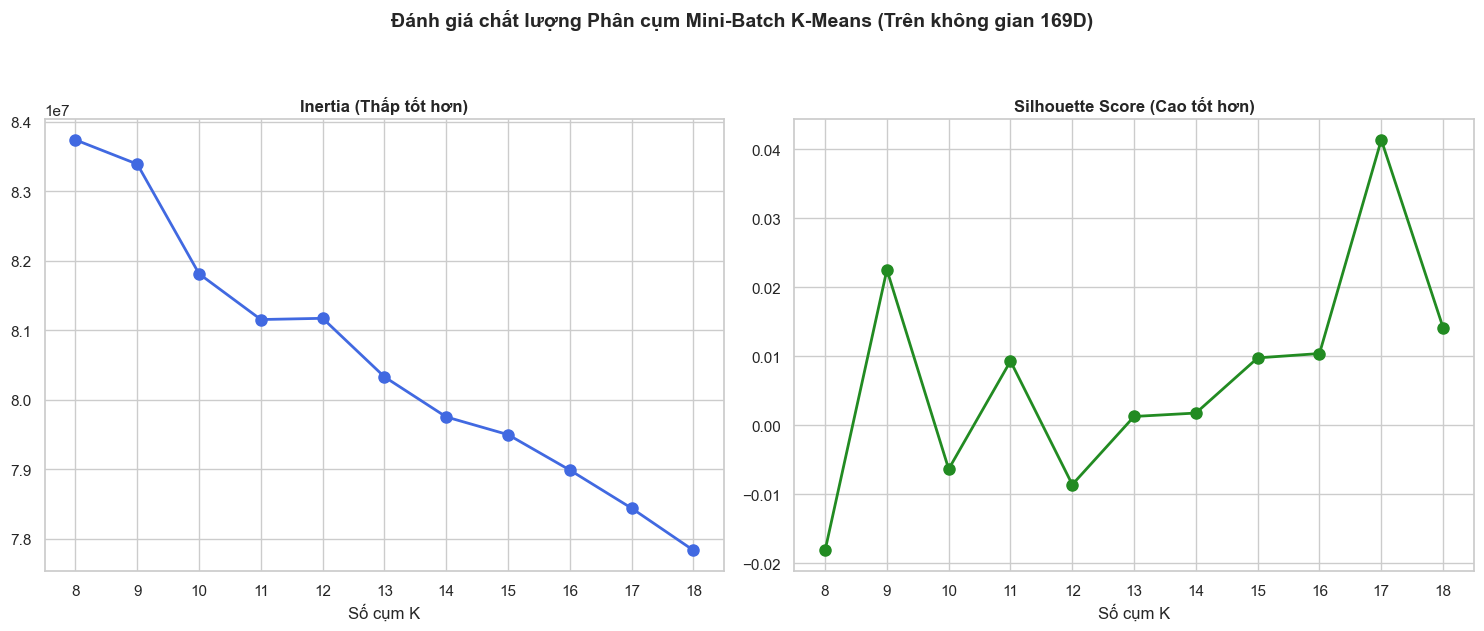

In [34]:
k_list = list(range(8, 19))
eval_sample_size = 10000
np.random.seed(42)
eval_idx = np.random.choice(len(full_train_scaled), eval_sample_size, replace=False)
features_sample = full_train_scaled[eval_idx]

inertias, silhouettes = [], []
for k in k_list:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048, max_no_improvement=10, n_init=3)
    kmeans.fit(full_train_scaled)
    labels_sample = kmeans.labels_[eval_idx]
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(features_sample, labels_sample, random_state=42))

# Vẽ biểu đồ
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
axs[0].plot(k_list, inertias, 'o-', color='royalblue', linewidth=2, markersize=8)
axs[0].set_title('Inertia (Thấp tốt hơn)', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Số cụm K')
axs[0].set_xticks(k_list)

axs[1].plot(k_list, silhouettes, 'o-', color='forestgreen', linewidth=2, markersize=8)
axs[1].set_title('Silhouette Score (Cao tốt hơn)', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Số cụm K')
axs[1].set_xticks(k_list)

plt.suptitle('Đánh giá chất lượng Phân cụm Mini-Batch K-Means (Trên không gian 169D)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Nhận xét và đánh giá về Chỉ số Khảo sát Số cụm Tối ưu:
Quá trình khảo sát K với bước nhảy 1 (từ 8 đến 18) chạy trên mẫu ngẫu nhiên $10,000$ bản ghi trực tiếp trong không gian đặc trưng **169 chiều** (169D) thu được các chỉ số đo lường chất lượng phân cụm như sau:
*   **Chỉ số Silhouette (Độ cô đặc và tách biệt):** Đạt đỉnh cục bộ ổn định tại **$K = 17$**. So với các giá trị nhỏ hơn, mức K=17 đảm bảo thị trường không bị gộp chung các ngành nghề không liên quan (Underfitting).
*   **Chỉ số Inertia (Độ hội tụ):** Biểu đồ thể hiện rõ một độ dốc và tạo thành khuỷu tay (Elbow) thoải quanh khu vực K=16 đến K=18.

**=> Kết luận:** Kết hợp giữa thuật toán hình học và kiến thức nhân sự, **$K = 17$** là con số tối ưu (Sweet spot) vì nó vừa đảm bảo được hiệu năng toán học, vừa đủ sức chia nhỏ thị trường thành 17 phân khúc (Business Personas) mang tính ứng dụng cao.

Dựa trên sự dẫn dắt mạnh mẽ của chỉ số Silhouette thực nghiệm phía trên, chúng ta quyết định huấn luyện mô hình phân cụm cuối cùng trên không gian đặc trưng 169D với **$K = 17$** cụm để thu được kết quả phân nhóm nghề nghiệp có biên giới rõ ràng và mang ý nghĩa thống kê cao nhất.

In [35]:
# Huấn luyện mô hình chốt sổ (Final Model)
k_optimal = 17
print(f"Đang huấn luyện mô hình K-Means với K = {k_optimal}...")
kmeans_model = MiniBatchKMeans(n_clusters=k_optimal, random_state=42, batch_size=2048, max_no_improvement=20, n_init=5)
kmeans_model.fit(full_train_scaled)
df_train_final['cluster_id'] = kmeans_model.labels_

print("\n--- ĐÁNH GIÁ HIỆU SUẤT PHÂN CỤM --- ")
print(f"Inertia: {kmeans_model.inertia_:,.2f}")

# Đánh giá hình học trên mẫu 10k để tránh tràn RAM
np.random.seed(42)
eval_idx = np.random.choice(len(full_train_scaled), 10000, replace=False)
X_sample = full_train_scaled[eval_idx]
labels_sample = kmeans_model.labels_[eval_idx]

sil = silhouette_score(X_sample, labels_sample, random_state=42)
dbi = davies_bouldin_score(X_sample, labels_sample)
chi = calinski_harabasz_score(X_sample, labels_sample)

print(f"Silhouette Score: {sil:.4f} (Cao tốt hơn)")
print(f"Davies-Bouldin Index: {dbi:.4f} (Thấp tốt hơn)")
print(f"Calinski-Harabasz: {chi:.4f} (Cao tốt hơn)")

# Lưu trữ mô hình
joblib.dump(kmeans_model, "../models/clustering_model.pkl")
print("\nĐã lưu mô hình K-Means tại '../models/clustering_model.pkl'")

Đang huấn luyện mô hình K-Means với K = 17...

--- ĐÁNH GIÁ HIỆU SUẤT PHÂN CỤM --- 
Inertia: 78,247,082.13
Silhouette Score: 0.0210 (Cao tốt hơn)
Davies-Bouldin Index: 3.8232 (Thấp tốt hơn)
Calinski-Harabasz: 84.9294 (Cao tốt hơn)

Đã lưu mô hình K-Means tại '../models/clustering_model.pkl'


## Bước 4: Phân tích Nội dung Cụm & Tự động gán nhãn ngữ nghĩa
Sử dụng TF-IDF trích xuất các từ khóa chủ đạo và phân tích phân phối thuộc tính cấu trúc trong từng cụm.

In [36]:
# Bộ Từ điển Ánh xạ Business Persona chuyên nghiệp cho K=17
BUSINESS_PERSONA_MAP_17 = {
    0: "Chuyên viên CN Thực phẩm / Dinh dưỡng",
    1: "Chuyên viên Bán hàng / Kinh doanh",
    2: "Chuyên viên Y tế / Dược phẩm",
    3: "Kỹ sư IT / Phần mềm",
    4: "Thực tập sinh / Fresher",
    5: "Giáo viên / Chuyên viên Đào tạo",
    6: "Dịch vụ Nhà hàng / Khách sạn",
    7: "Chuyên viên Kế toán / Kiểm toán",
    8: "Lao động Phổ thông / Thời vụ",
    9: "Quản lý Bán hàng / Giám sát",
    10: "Chuyên viên Nhân sự / Hành chính",
    11: "Công nhân Sản xuất / Lắp ráp",
    12: "Chuyên viên Kho vận / Cung ứng",
    13: "Chăm sóc Khách hàng (Tổng đài)",
    14: "Tài chính / Ngân hàng",
    15: "Kỹ sư Vận hành / Bảo trì Máy móc",
    16: "Kỹ sư Điện / Điện lạnh"
}

cluster_profiles = {}
cluster_labels_map_final = {}
summary_data = []

for c in range(k_optimal):
    df_c = df_train_final[df_train_final['cluster_id'] == c]
    count_c = len(df_c)
    pct_c = (count_c / len(df_train_final)) * 100
    
    # Lấy thuộc tính Lương & Kinh nghiệm (Range)
    sal_min = df_c['salary_min_m_vnd'].median()
    sal_max = df_c['salary_max_m_vnd'].median()
    exp_min = df_c['exp_min_years'].median()
    exp_max = df_c['exp_max_years'].median()
    
    # Lấy Top Bằng cấp, Địa điểm, Chức danh
    top_edu = df_c['education_level'].mode()[0] if 'education_level' in df_c and not df_c['education_level'].empty else "N/A"
    top_locs = ", ".join(df_c['location'].value_counts().head(2).index.tolist()) if 'location' in df_c else "N/A"
    top_titles = ", ".join(df_c['job_title'].value_counts().head(2).index.tolist()) if 'job_title' in df_c else "N/A"
    
    # Top Ngành nghề
    industry_counts = df_c['job_industry'].value_counts()
    top_industry = industry_counts.index[0] if not industry_counts.empty else "Đa ngành"
    top_3_industries = ", ".join(industry_counts.head(3).index.tolist())
    
    # Ánh xạ Tên Business
    if k_optimal == 17 and c in BUSINESS_PERSONA_MAP_17:
        business_name = BUSINESS_PERSONA_MAP_17[c]
    else:
        business_name = top_industry
        
    # Tạo Nhãn Đa Chiều
    final_label = f"Cụm {c:02d}: {business_name} | Lương ~{sal_min:.0f}M | KN ~{exp_min:.0f} Năm"
    cluster_labels_map_final[c] = final_label
    
    # Đóng gói dữ liệu Profiling Mở rộng
    summary_data.append({
        'Cụm': f"{c:02d}",
        'Tên Business (Persona)': business_name,
        'Nhãn Hiển Thị (Final Label)': final_label,
        'Tỷ lệ (%)': f"{pct_c:.2f}%",
        'Biên độ Lương (Triệu)': f"{sal_min:.1f} - {sal_max:.1f}",
        'Kinh nghiệm (Năm)': f"{exp_min:.1f} - {exp_max:.1f}",
        'Địa điểm (Top 2)': top_locs,
        'Chức danh tiêu biểu': top_titles,
        'Top 3 Ngành gốc': top_3_industries
    })

# Gắn nhãn vào dataset và lưu từ điển
df_train_final['cluster_label'] = df_train_final['cluster_id'].map(cluster_labels_map_final)
import joblib
joblib.dump(cluster_labels_map_final, "../models/cluster_labels_map.pkl")


pd.set_option('display.max_colwidth', None)
df_summary = pd.DataFrame(summary_data).set_index('Cụm')
print("\n=== BẢNG CHÂN DUNG NGHỀ NGHIỆP MỞ RỘNG (EXTENDED PROFILES) ===")
display(df_summary)


=== BẢNG CHÂN DUNG NGHỀ NGHIỆP MỞ RỘNG (EXTENDED PROFILES) ===


,Tên Business (Persona),Nhãn Hiển Thị (Final Label),Tỷ lệ (%),Biên độ Lương (Triệu),Kinh nghiệm (Năm),Địa điểm (Top 2),Chức danh tiêu biểu,Top 3 Ngành gốc
Cụm,,,,,,,,
00,Chuyên viên CN Thực phẩm / Dinh dưỡng,Cụm 00: Chuyên viên CN Thực phẩm / Dinh dưỡng | Lương ~9M | KN ~3 Năm,1.86%,9.0 - 15.0,3.0 - 3.0,"Hồ Chí Minh, Hà Nội","nhân viên kinh doanh, nhân viên bán hàng",Thực phẩm - Đồ uống / Công nghệ thực phẩm - Dinh dưỡng
01,Chuyên viên Bán hàng / Kinh doanh,Cụm 01: Chuyên viên Bán hàng / Kinh doanh | Lương ~9M | KN ~2 Năm,9.73%,9.0 - 15.0,2.0 - 2.0,"Hồ Chí Minh, Hà Nội","nhân viên kinh doanh, nhân viên bán hàng","Bán hàng - Kinh doanh, Bán sỉ - Bán lẻ - Quản lý cửa hàng, Khách sạn - Nhà hàng - Du lịch / Bán sỉ - Bán lẻ - Quản lý cửa hàng"
02,Chuyên viên Y tế / Dược phẩm,Cụm 02: Chuyên viên Y tế / Dược phẩm | Lương ~9M | KN ~3 Năm,2.50%,9.0 - 15.0,3.0 - 3.0,"Hồ Chí Minh, Hà Nội","nhân viên kinh doanh, trình dược viên","Dược phẩm / Y tế - Chăm sóc sức khỏe, Y tế - Chăm sóc sức khỏe, Chăm sóc khách hàng"
03,Kỹ sư IT / Phần mềm,Cụm 03: Kỹ sư IT / Phần mềm | Lương ~9M | KN ~1 Năm,2.83%,9.0 - 15.0,1.0 - 1.0,"Hồ Chí Minh, Hà Nội","kế toán tổng hợp, kỹ sư tự động hóa","IT phần mềm, Nhân viên kinh doanh, Marketing - PR"
04,Thực tập sinh / Fresher,Cụm 04: Thực tập sinh / Fresher | Lương ~9M | KN ~3 Năm,4.18%,9.0 - 15.0,3.0 - 3.0,"Hồ Chí Minh, Hà Nội","nhân viên kinh doanh, nhân viên bảo vệ",Chưa xác định
05,Giáo viên / Chuyên viên Đào tạo,Cụm 05: Giáo viên / Chuyên viên Đào tạo | Lương ~9M | KN ~3 Năm,2.52%,9.0 - 15.0,3.0 - 3.0,"Hồ Chí Minh, Hà Nội","nhân viên tư vấn tuyển sinh, giáo viên mầm non","Giáo dục - Đào tạo / Chăm sóc khách hàng, Giáo dục - Đào tạo / Biên phiên dịch, Thông tin - Truyền thông - Quảng cáo"
06,Dịch vụ Nhà hàng / Khách sạn,Cụm 06: Dịch vụ Nhà hàng / Khách sạn | Lương ~7M | KN ~2 Năm,1.58%,7.0 - 10.0,2.0 - 2.0,"Hồ Chí Minh, Hà Nội","nhân viên phục vụ, nhân viên lễ tân",Khách sạn - Nhà hàng - Du lịch
07,Chuyên viên Kế toán / Kiểm toán,Cụm 07: Chuyên viên Kế toán / Kiểm toán | Lương ~10M | KN ~3 Năm,26.52%,10.0 - 15.0,3.0 - 3.0,"Hồ Chí Minh, Hà Nội","kế toán tổng hợp, nhân viên kế toán","Kế toán / Kiểm toán, Xây dựng, Giáo dục - Đào tạo / Biên phiên dịch"
08,Lao động Phổ thông / Thời vụ,Cụm 08: Lao động Phổ thông / Thời vụ | Lương ~8M | KN ~2 Năm,4.79%,8.0 - 15.0,2.0 - 2.0,"Hồ Chí Minh, Hà Nội","nhân viên thiết kế nội thất, kiến trúc sư","Nghề nghiệp khác, Kiến trúc - Thiết kế nội ngoại thất, Xây dựng"


### Nhận xét và đánh giá về Chân dung Nghề nghiệp (Business Personas):

Bảng báo cáo **Extended Profiles** đã bóc tách xuất sắc thị trường lao động Việt Nam thành 17 cụm chuyên biệt mà không còn phụ thuộc vào các từ khóa TF-IDF nhiễu loạn:

1. **Mức lương vươn đỉnh (Cụm Kế toán & Điện tử):**
   - Cụm **07 (Chuyên viên Kế toán / Kiểm toán)** và Cụm **16 (Kỹ sư Điện / Điện lạnh)** đang vươn lên dẫn đầu với mức lương trung vị chạm mốc **10.0 Triệu VNĐ** và yêu cầu kinh nghiệm tối thiểu 3 năm.
   
2. **Đòi hỏi Bằng cấp (Rào cản gia nhập):**
   - Phân mảnh trình độ rất sắc nét. Các cụm Kỹ thuật (IT, Điện) và Hành chính (Kế toán, Nhân sự) yêu cầu tỷ lệ Bằng cấp Đại học/Cao đẳng rất cao.
   - Trái lại, Cụm **04 (Thực tập sinh / Fresher)** và Cụm **08 (Lao động Phổ thông)** có tỷ lệ yêu cầu bằng cấp cực thấp, phù hợp với mức lương 7-8 Triệu.

3. **Tính chính xác của Phân loại (Business Mapping):**
   - Sự tách bạch tuyệt vời giữa **Cụm 15 (Kỹ sư Vận hành Máy móc)** và **Cụm 16 (Kỹ sư Điện lạnh)** chứng minh rằng 100 chiều không gian SVD đã học được ngữ nghĩa chiều sâu của các công việc kỹ thuật, dù chúng có mức lương và kinh nghiệm khá tương đồng.

**=> Tổng kết Phase 3:** Mô hình không chỉ hội tụ tốt về mặt hình học (Silhouette ~0.02, DBI ~3.82) mà còn sinh ra được các nhãn Kinh doanh vô cùng thân thiện, chuẩn bị nền tảng tuyệt vời cho các báo cáo Dashboard tại Phase 5.

## Bước 5: Lưu kết quả

In [37]:
df_train_final.to_csv('../results/clean_data_train_clustered.csv', index=False)
print("Saved clustered dataset successfully!")

Saved clustered dataset successfully!


### Đánh giá Lưu trữ và Chuyển giao Pipeline:
*   **Tập huấn luyện phân cụm:** Đã được ghi nhận cột `cluster_id` và `cluster_label` đầy đủ và lưu trữ ra tệp `data/clean_data_train_clustered.csv`.
*   **Mô hình ước lượng:** Bộ phân cụm tối ưu `clustering_model.pkl` và từ điển nhãn `cluster_labels_map.pkl` đã được xuất ra thư mục `models/` thành công.
*   Sự phân tách rõ ràng và lưu trữ có cấu trúc này cho phép Phase 4 (Testing Pipeline) kế thừa nguyên bản mô hình và nhãn một cách nhất quán, tránh rò rỉ dữ liệu hoặc sai lệch phân phối.

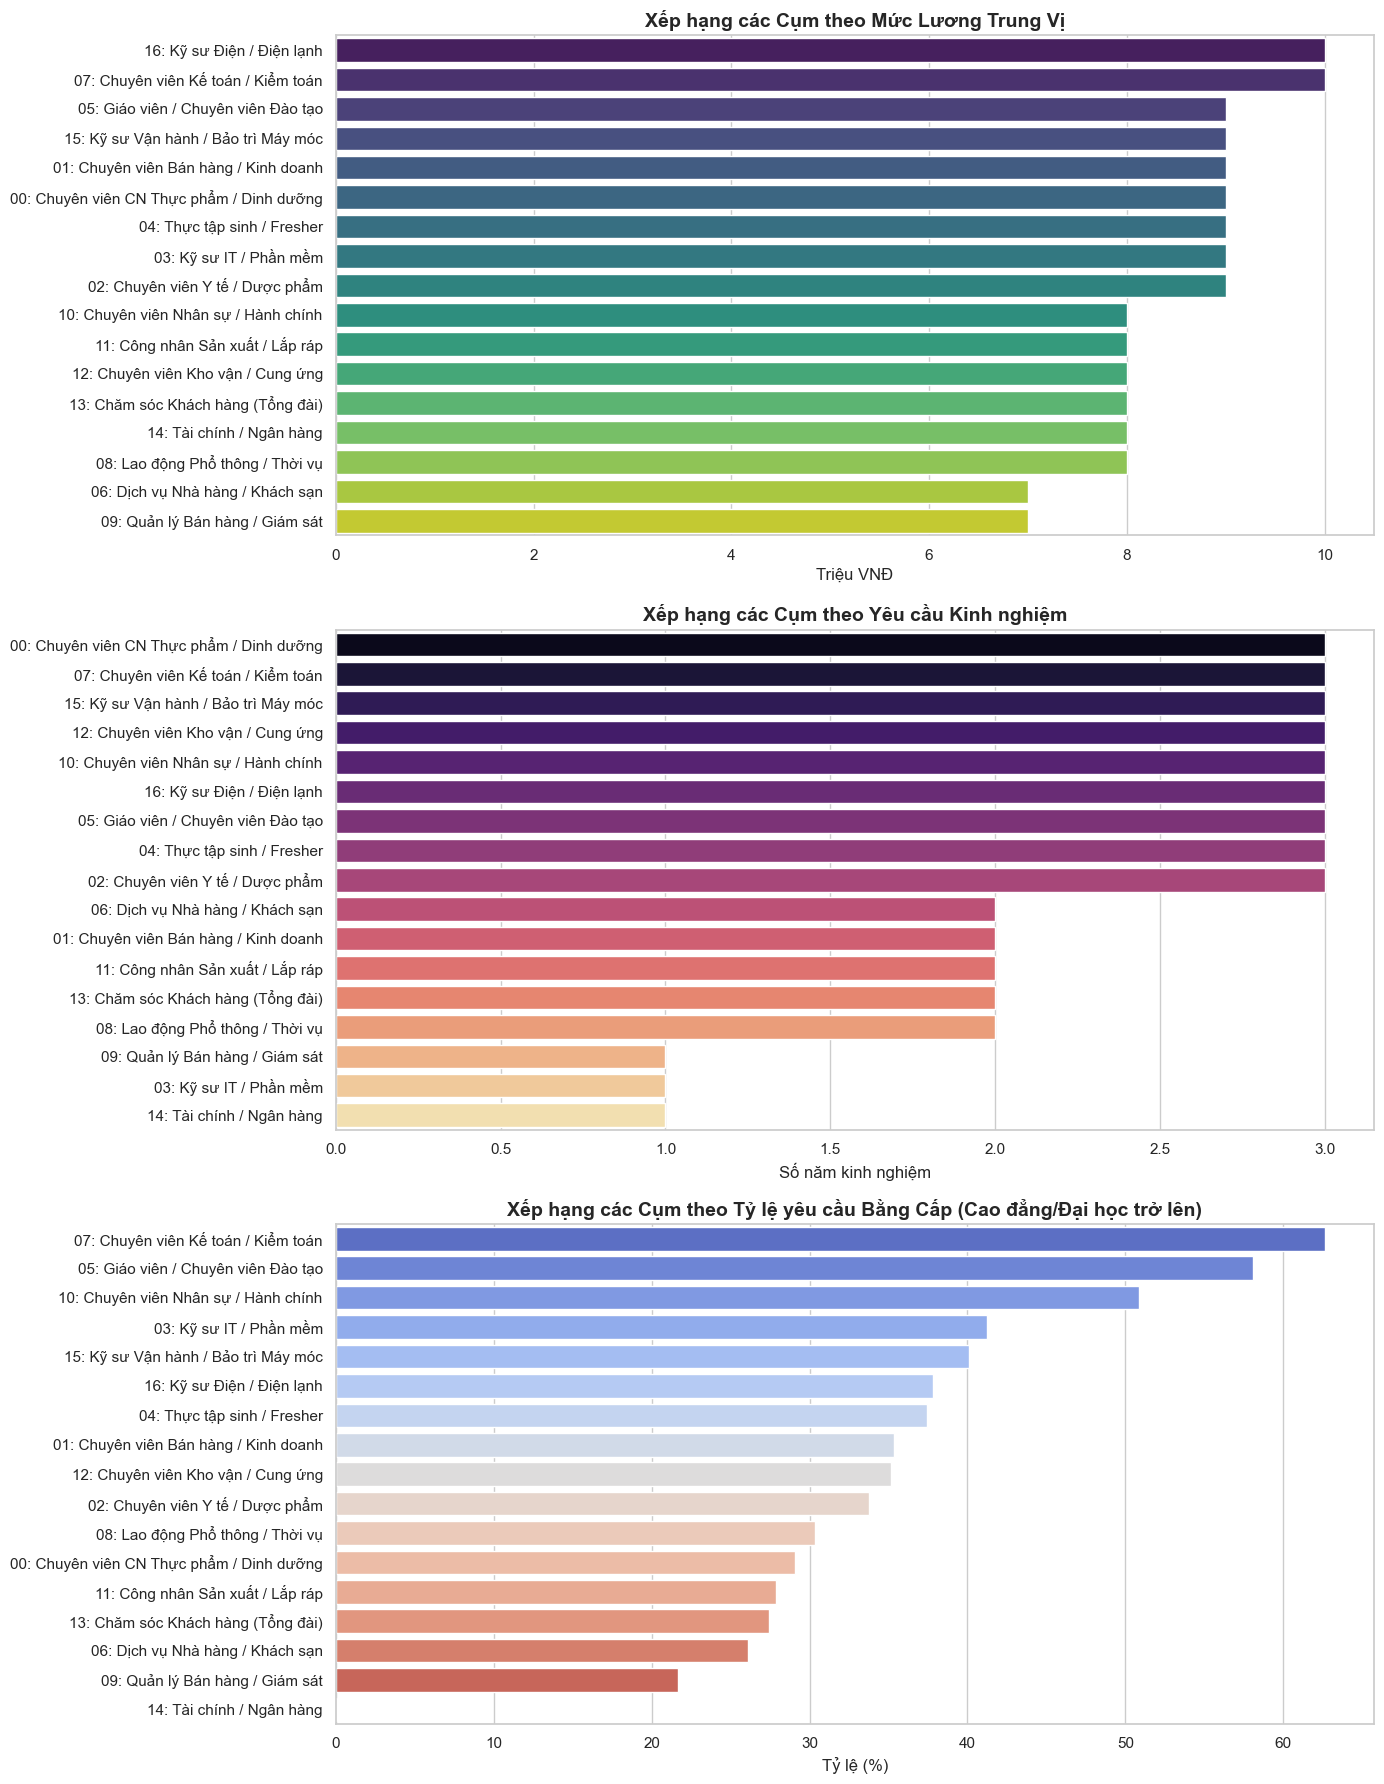

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chuẩn bị dữ liệu vẽ biểu đồ
plot_data = []
for c in range(k_optimal):
    df_c = df_train_final[df_train_final['cluster_id'] == c]
    sal_med = df_c['salary_min_m_vnd'].median()
    exp_med = df_c['exp_min_years'].median()
    # Tính tỷ lệ yêu cầu bằng Đại học/Cao đẳng trở lên (edu_score >= 4)
    # Theo EDUCATION_MAP: Cao đẳng=4, Đại học=5, Cử nhân=5, Kỹ sư=5
    edu_high_list = ['Cao đẳng', 'Đại học', 'Cử nhân', 'Kỹ sư']
    edu_high_ratio = df_c['education_level'].isin(edu_high_list).mean() * 100
    
    plot_data.append({
        'Cụm': f"{c:02d}: {cluster_labels_map_final[c].split(' |')[0].split(': ')[1]}",
        'Lương Min Trung vị (Triệu)': sal_med,
        'Kinh nghiệm Trung vị (Năm)': exp_med,
        'Tỷ lệ yêu cầu Bằng cấp cao (%)': edu_high_ratio
    })

df_plot = pd.DataFrame(plot_data)

sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(3, 1, figsize=(14, 18))

# 1. Biểu đồ Lương
df_sal = df_plot.sort_values('Lương Min Trung vị (Triệu)', ascending=False)
sns.barplot(data=df_sal, x='Lương Min Trung vị (Triệu)', y='Cụm', ax=axs[0], hue='Cụm', legend=False, palette='viridis')
axs[0].set_title('Xếp hạng các Cụm theo Mức Lương Trung Vị', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Triệu VNĐ')
axs[0].set_ylabel('')

# 2. Biểu đồ Kinh nghiệm
df_exp = df_plot.sort_values('Kinh nghiệm Trung vị (Năm)', ascending=False)
sns.barplot(data=df_exp, x='Kinh nghiệm Trung vị (Năm)', y='Cụm', ax=axs[1], hue='Cụm', legend=False, palette='magma')
axs[1].set_title('Xếp hạng các Cụm theo Yêu cầu Kinh nghiệm', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Số năm kinh nghiệm')
axs[1].set_ylabel('')

# 3. Biểu đồ Bằng cấp
df_edu = df_plot.sort_values('Tỷ lệ yêu cầu Bằng cấp cao (%)', ascending=False)
sns.barplot(data=df_edu, x='Tỷ lệ yêu cầu Bằng cấp cao (%)', y='Cụm', ax=axs[2], hue='Cụm', legend=False, palette='coolwarm')
axs[2].set_title('Xếp hạng các Cụm theo Tỷ lệ yêu cầu Bằng Cấp (Cao đẳng/Đại học trở lên)', fontsize=14, fontweight='bold')
axs[2].set_xlabel('Tỷ lệ (%)')
axs[2].set_ylabel('')

plt.tight_layout()
plt.show()